In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [52]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

!wget $data -O course_lead_scoring_2026.csv

/bin/bash: wget: command not found


In [53]:
df = pd.read_csv('course_lead_scoring_2026.csv')

In [54]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [55]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [56]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [57]:
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='str')

In [58]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='str').columns.tolist()

df_num = df[num_cols]
df_cat = df[cat_cols]

In [59]:
df_num.fillna(0.0, inplace=True)
df_cat.fillna('NA', inplace=True)

,lead_source,industry,employment_status,location
0,organic_search,technology,employed,europe
1,social_media,technology,employed,south_america
2,referral,retail,employed,europe
3,paid_ads,manufacturing,student,NA
4,referral,manufacturing,student,north_america
...,...,...,...,...
4995,organic_search,education,employed,asia
4996,NA,technology,employed,north_america
4997,organic_search,finance,employed,asia
4998,referral,technology,employed,africa


In [60]:
df_prep = pd.concat([df_num, df_cat], axis=1)

In [61]:
df_full_train, df_test = train_test_split(df_prep, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

Question 1

In [62]:
from sklearn.metrics import roc_auc_score

df_num_auc = df_train[num_cols]
y_num_auc = df_num_auc["converted"]

num_feat_importance = {}

for col in num_cols:
    auc = roc_auc_score(y_num_auc, df_num_auc[col])
    num_feat_importance[col] = auc

print(num_feat_importance)


{'annual_income': 0.6081977776250831, 'number_of_courses_viewed': 0.7229894623989618, 'interaction_count': 0.7649203047563227, 'lead_score': 0.7882254810906102, 'converted': 1.0}


lead_score has the highest AUC.

Question 2

In [63]:
y_train = df_train['converted']
y_val = df_val['converted']
y_test = df_test['converted']

del df_train['converted']
del df_val['converted']
del df_test['converted']

df_train.shape

(3000, 8)

In [64]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
val_dict = df_val.to_dict(orient='records')


X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)

In [65]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

In [69]:
auc = roc_auc_score(y_val, y_pred)
print(f"AUC: {auc:.3f}")

AUC: 0.598


Question 3

In [ ]:
y_pred_proba = model.predict_proba(X_val)


array([[0.45527705, 0.54472295],
       [0.20994773, 0.79005227],
       [0.49022056, 0.50977944],
       ...,
       [0.24221364, 0.75778636],
       [0.22098612, 0.77901388],
       [0.59553414, 0.40446586]], shape=(1000, 2))

In [82]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred_proba[:, 1] >= t)
    predict_negative = (y_pred_proba[:, 1] < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    scores.append((t, tp, fp, fn, tn))

columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)


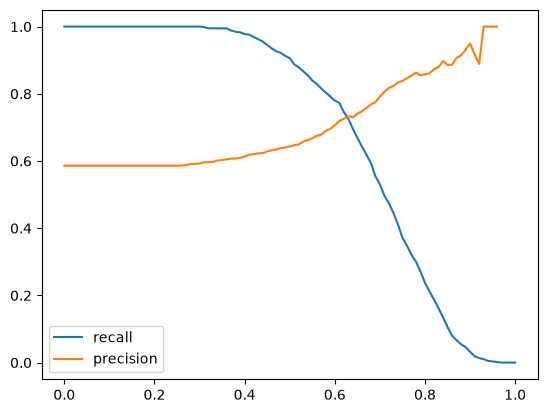

In [84]:
from matplotlib import pyplot as plt

plt.plot(df_scores.threshold, df_scores['recall'], label='recall')
plt.plot(df_scores.threshold, df_scores['precision'], label='precision')
plt.legend()

The threshold with the smallest absolute difference between precision and recall is 0.63 (the intersection of the curves)

Question 4

In [85]:
df_scores["F1"] = 2 * df_scores['precision'] * df_scores['recall'] / (df_scores['precision'] + df_scores['recall'])

In [94]:
df_scores["threshold"][df_scores["F1"].idxmax()]

np.float64(0.41000000000000003)

The threshold for which F1 is maximal is 0.41

Question 5

In [112]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=1)

In [121]:
def train(df_train, y_train, C):
    df_train_drop = df_train[cat_cols + num_cols].drop(columns=["converted"])

    dicts = df_train_drop.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

def predict(df, dv, model):
    df_train_drop = df[cat_cols + num_cols].drop(columns=["converted"])

    dicts = df_train_drop.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [122]:
from tqdm.auto import tqdm

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=1.0)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.732 +- 0.007


The standard deviation for the AUC scores between the different folds is 0.007

Question 6

In [124]:
for c in [0.000001, 0.001, 1]:
    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=c)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (c, np.mean(scores), np.std(scores)))    

C=1e-06 0.617 +- 0.019
C=0.001 0.749 +- 0.010
C=1 0.732 +- 0.007


C=0.001 leads to the best ROC AUC (0.749)